In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [16]:
import gc, random
from pathlib import Path

import torch
import numpy as np
from scipy.spatial.distance import pdist

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.preprocessing import normalize

# Import your modules
from src.dino import ConvNeXtV2
from src.dataset import SonarDataset, SonarDataTransform
from src.utils import show_images, load_backbone, run_inference

WEIGHTS_DIR = Path("../weights/")
EPOCH_COUNT = len(list(WEIGHTS_DIR.iterdir())) - 2

DEVICE = torch.device("cuda")  # ConvNeXtV2 doesn't support CPU

SEED = 42
NUM_SAMPLES = 10_000  # For ablation tests
DATASET = SonarDataset(data_dir="../data/processed/")
N = len(DATASET)

In [3]:
def get_outputs(model: ConvNeXtV2):
    transform = SonarDataTransform()

    patches = []

    embeds = []  # (4N, 768)
    for i in range(NUM_SAMPLES):
        patch = transform(DATASET[i * N // NUM_SAMPLES])

        # Save patches of invariance visual
        patches.append(patch['teacher']['global_crops'][0])

        for c in range(2):
            for m in ('teacher', 'student'):
                p = patch[m]['global_crops'][c]
                cls, _, _ = run_inference(model, p, normalize=False)
                embeds.append(cls)

    return patches, np.array(embeds)


def compute_alignment_and_uniformity(X_1, X_2, alpha=2.0, t=2.0):
    """
    Computes Alignment and Uniformity for two views of features.
    Lower values indicate better alignment and better uniformity.

    Alignment measures if two DIFFERENT augmented views of the SAME image
    are mapped closely together. Values in range [0.0, 4.0].

    Uniformity measures how well spread-out the feature space is.
    Values in range [-4.0, 0.0].

    Args:
        X_1: numpy array of shape (n, c) - View 1
        X_2: numpy array of shape (n, c) - View 2 (positive pairs to View 1)

    Returns:
        tuple: (alignment_score, uniformity_score)
    """
    X_1_norm = normalize(X_1, norm='l2', axis=1)  # (N, 768)
    X_2_norm = normalize(X_2, norm='l2', axis=1)  # (N, 768)

    # Compute Alignment (expected squared distance between positive pairs)
    distances_sq = np.power(np.linalg.norm(X_1_norm - X_2_norm, axis=1), alpha)

    alignment = np.mean(distances_sq)

    # Compute Uniformity: Evaluates how evenly distributed the features are by looking at all negative pairs.
    X_combined = np.concatenate([X_1_norm, X_2_norm], axis=0)
    sq_pairwise_distances = pdist(X_combined, metric='sqeuclidean')

    uniformity = np.log(np.mean(np.exp(-t * sq_pairwise_distances)))

    return alignment, uniformity


def compute_invariance_score(X_orig, X_aug):
    """
    Computes the invariance of feature representations to a specific augmentation.

    Invariance tests how much a specific patch shifts when a specific
    augmentation is applied to it.

    Args:
        X_orig: numpy array of shape (n, c) - Features from original images
        X_aug: numpy array of shape (n, c) - Features from augmented images

    Returns:
        mean_invariance (float): The average cosine similarity across all pairs.
        sample_invariances (np.array): The individual cosine similarity per sample, shape (n,). Useful for plotting histograms.
    """
    X_orig_norm = normalize(X_orig, norm='l2', axis=1)  # (N, 768)
    X_aug_norm = normalize(X_aug, norm='l2', axis=1)  # (N, 768)

    # Cosine similarity per sample
    sample_invariances = np.sum(X_orig_norm * X_aug_norm, axis=1)

    # Calculate the overall mean invariance
    mean_invariance = np.mean(sample_invariances)

    return mean_invariance, sample_invariances


In [4]:
model = load_backbone(WEIGHTS_DIR / "checkpoint_latest.pth")
patches, embeds = get_outputs(model)

In [9]:
X_orig = embeds[0::4]  # Grabs indices 0, 4, 8, 12... (normalize(patch1))
X_aug  = embeds[1::4]  # Grabs indices 1, 5, 9, 13... (aug1)

mean_inv, sample_inv = compute_invariance_score(X_orig, X_aug)

X_1 = embeds[1::4]  # Grabs indices 1, 5, 9, 13... (aug1)
X_2 = embeds[3::4]  # Grabs indices 3, 7, 11, 15... (aug2)

alignment, uniformity = compute_alignment_and_uniformity(X_1, X_2)

print("==================================================")
print("              FEATURE SPACE ABLATION              ")
print("==================================================")

print("1. INVARIANCE PROBING (Augmentation Robustness)")
print("--------------------------------------------------")
print(f"   Mean Cosine Similarity:  {mean_inv:.4f}")
print(f"   Min Invariance (Worst):  {np.min(sample_inv):.4f}")
print(f"   Max Invariance (Best) :  {np.max(sample_inv):.4f}")
print(f"   Standard Deviation    :  {np.std(sample_inv):.4f}")
print()

print("2. ALIGNMENT & UNIFORMITY (Contrastive Metrics)")
print("--------------------------------------------------")
print(f"   Alignment Score       :  {alignment:.4f}")
print(f"   Uniformity Score      : -{np.abs(uniformity):.4f}")
print("==================================================")

              FEATURE SPACE ABLATION              
1. INVARIANCE PROBING (Augmentation Robustness)
--------------------------------------------------
   Mean Cosine Similarity:  0.9140
   Min Invariance (Worst):  0.0395
   Max Invariance (Best) :  1.0000
   Standard Deviation    :  0.1276

2. ALIGNMENT & UNIFORMITY (Contrastive Metrics)
--------------------------------------------------
   Alignment Score       :  0.8979
   Uniformity Score      : -3.1254


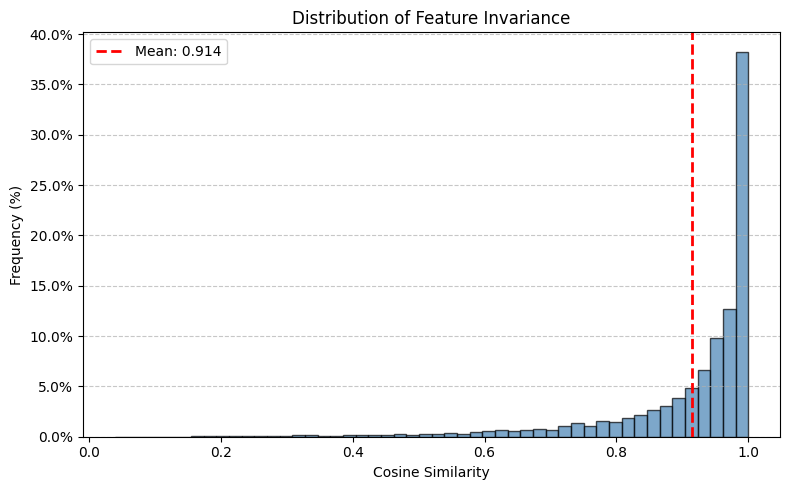

In [18]:
plt.figure(figsize=(8, 5))

# Calculate weights so the sum of all bins equals 1.0 (100%)
weights = np.ones_like(sample_inv) / len(sample_inv)

# Plot the histogram
plt.hist(sample_inv, bins=50, weights=weights, color='steelblue', edgecolor='black', alpha=0.7)

# Format the y-axis to display percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Add a vertical line for the mean
mean_val = np.mean(sample_inv)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.3f}')

# Formatting
plt.title("Distribution of Feature Invariance")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency (%)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

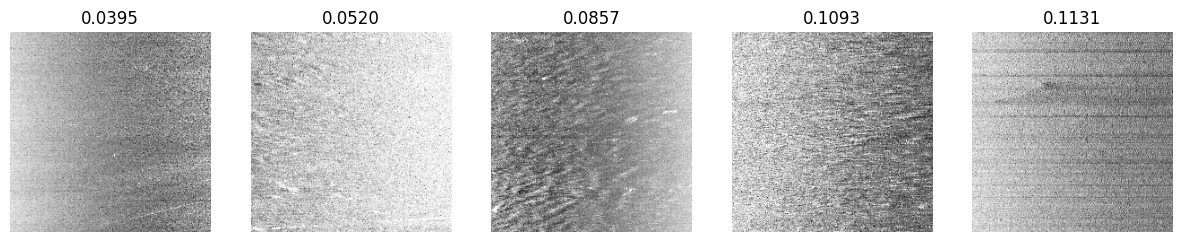

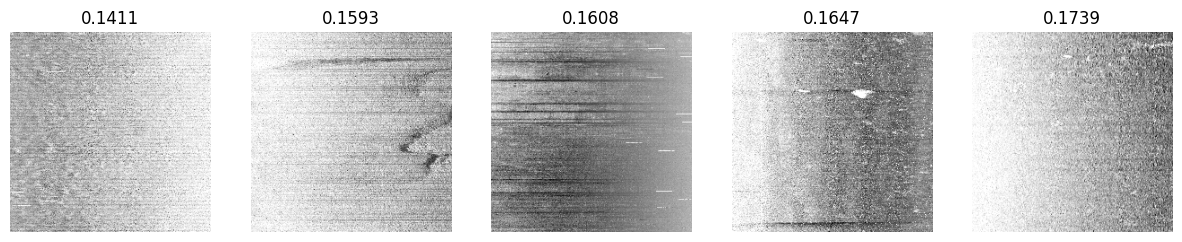

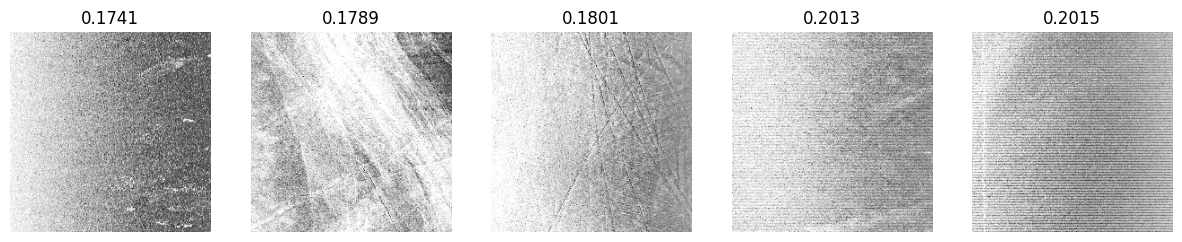

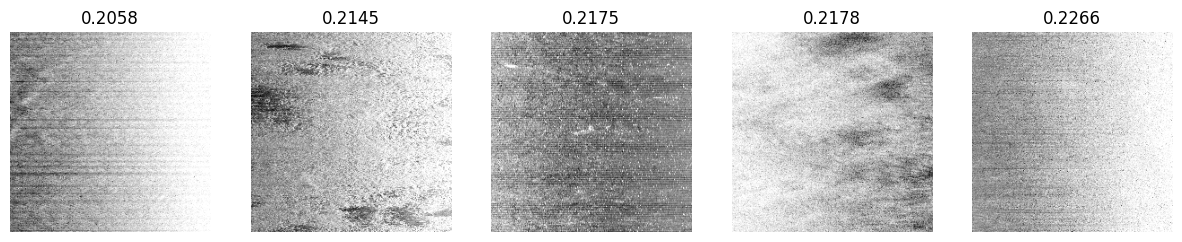

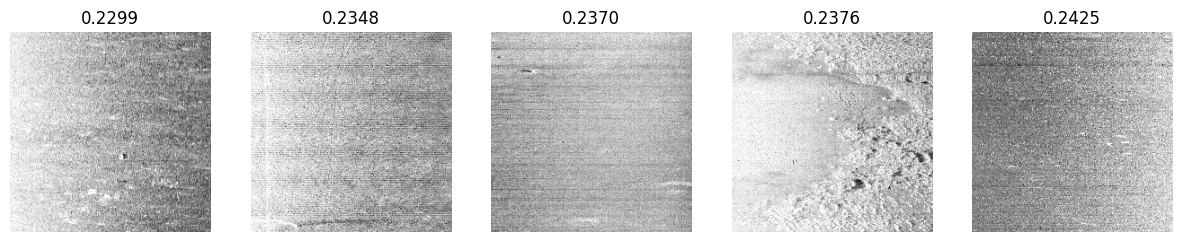

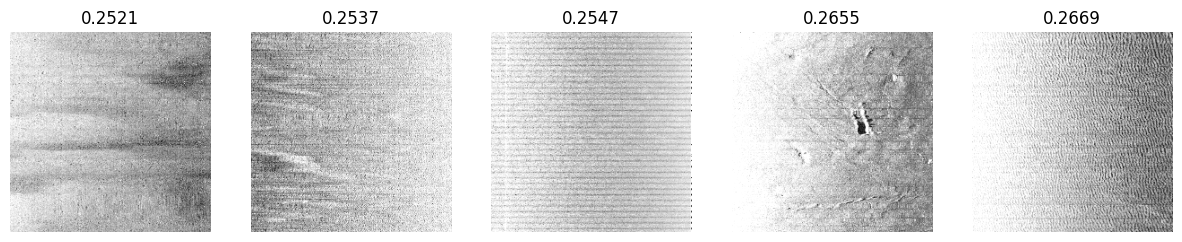

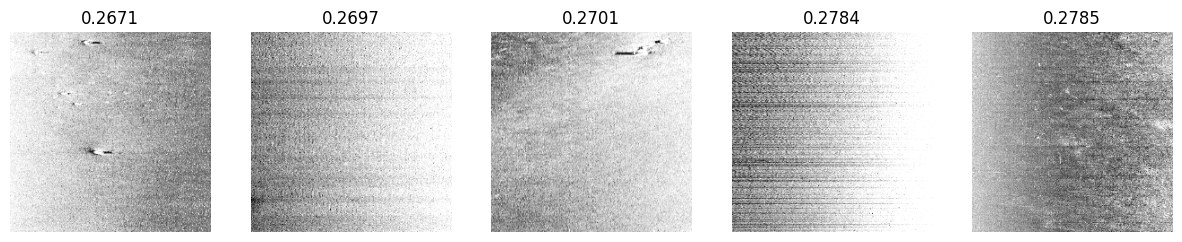

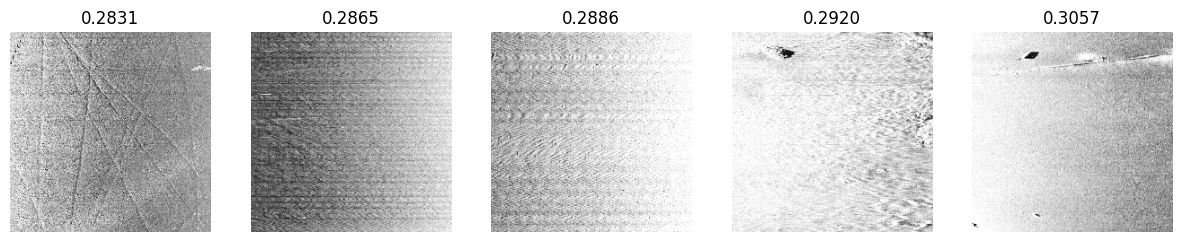

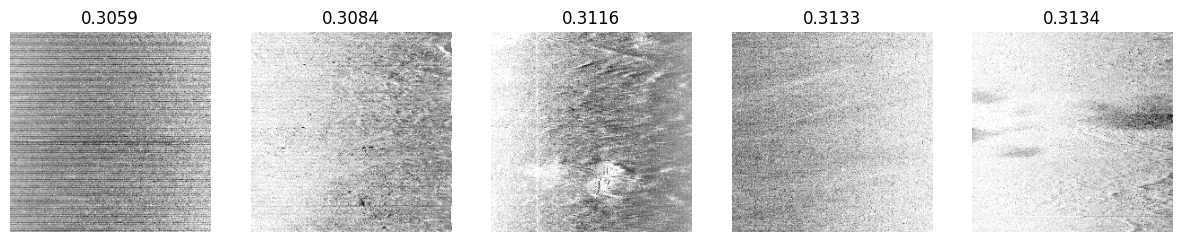

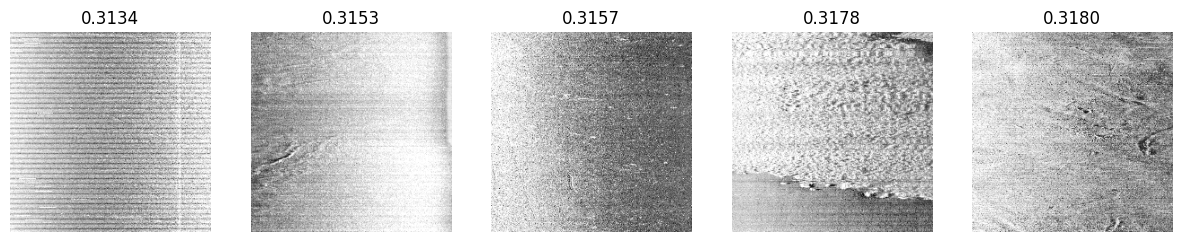

In [ ]:
idx = np.argsort(sample_inv)
for i in range(0, 50, 5):
    show_images([
        (patches[idx[i + j]], f'{sample_inv[idx[i + j]]:.4f}')
        for j in range(5)
    ])

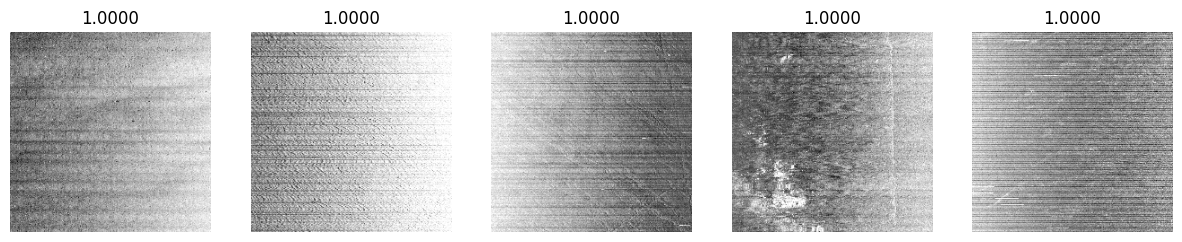

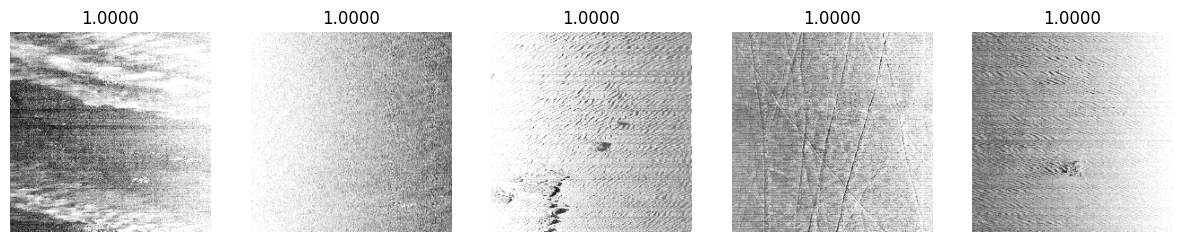

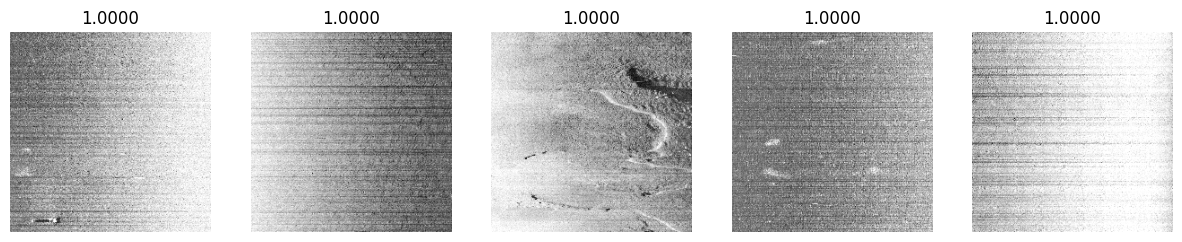

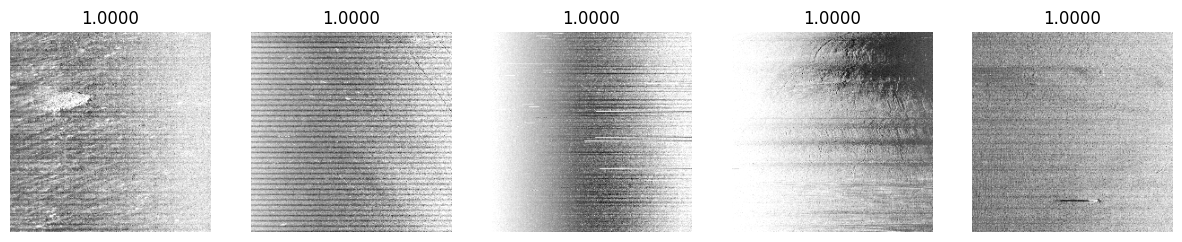

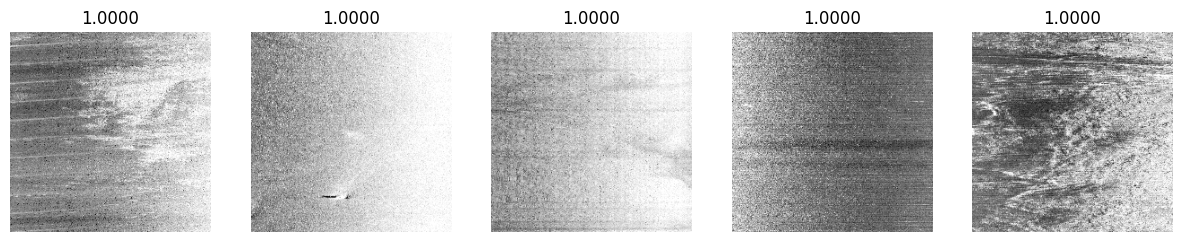

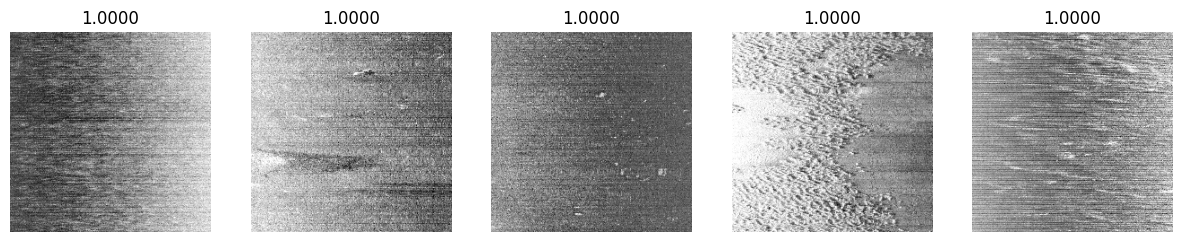

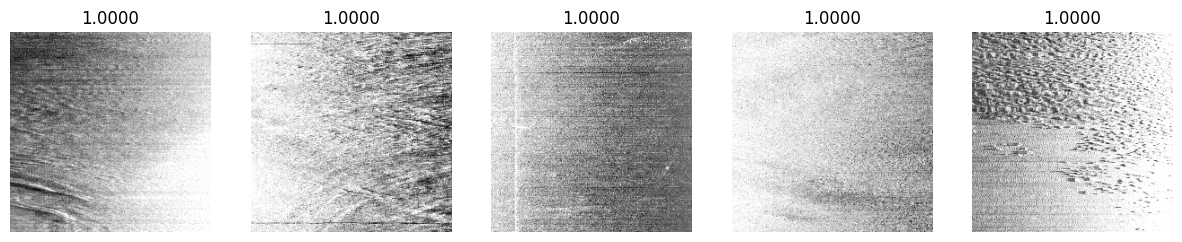

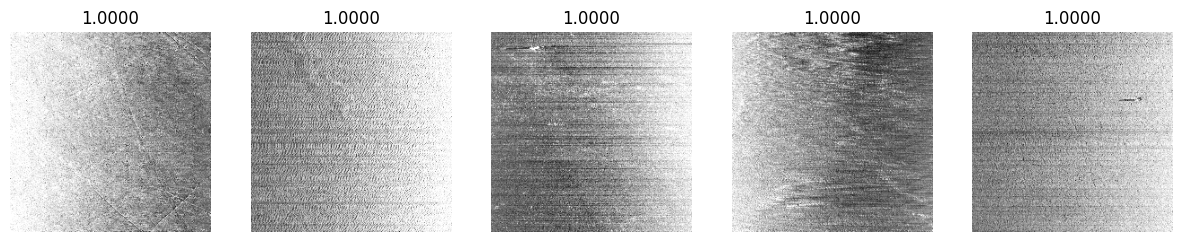

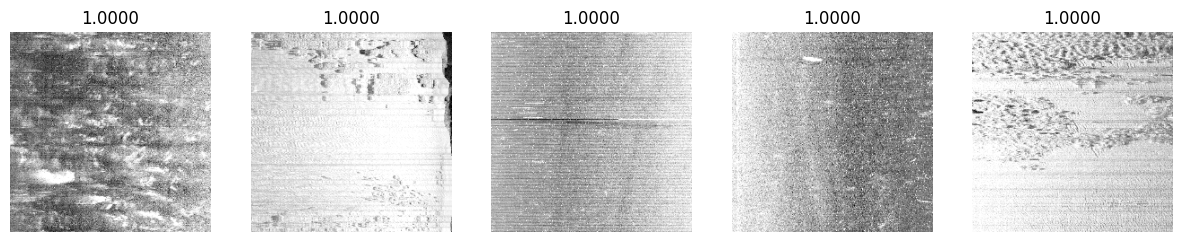

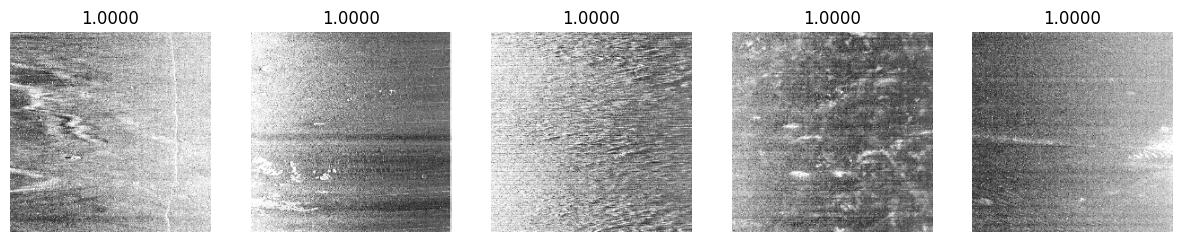

In [20]:
idx = np.argsort(sample_inv)[::-1]
for i in range(0, 50, 5):
    show_images([
        (patches[idx[i + j]], f'{sample_inv[idx[i + j]]:.4f}')
        for j in range(5)
    ])